In [79]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [43]:
df_hourly= pd.read_csv("../data/Processed/Solar_hourly_2021-2024.csv")

In [44]:
df_hourly["measured_on"]=pd.to_datetime(df_hourly["measured_on"])
df_hourly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16496 entries, 0 to 16495
Data columns (total 35 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   measured_on         16496 non-null  datetime64[ns, UTC]
 1   Power               16496 non-null  float64            
 2   Solar Zenith Angle  16496 non-null  float64            
 3   Aerosol_depth       16496 non-null  float64            
 4   Humidity            16496 non-null  float64            
 5   Surface Albedo      16496 non-null  float64            
 6   Wind Speed          16496 non-null  float64            
 7   Cloud Type          16496 non-null  float64            
 8   Pressure            16496 non-null  float64            
 9   Precipitable Water  16496 non-null  float64            
 10  Ozone               16496 non-null  float64            
 11  Temp                16496 non-null  float64            
 12  TotalCloudCover     16496 non-nu

In [88]:
#eXtreme Gradient Boost

from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
from sklearn.model_selection import TimeSeriesSplit
import shap



rmse_scores = [0]*3
r2_scores= [0]*3

#DeltaT(0-3) is column with difference between temperature at t hrs and temperature at t-3 hrs
cols = [ 'Temp', 'DeltaT(0-3)', 'Power_factor_inv1', 'Power_factor_inv2', 'Cloud Type', 'TotalCloudCover', 'Humidity', 'Zenith','day_of_year','DeltaT(0-1)']


X = df_hourly[cols]
y = df_hourly['Power']

tscv = TimeSeriesSplit(n_splits=3)

for i, (train_idx, val_idx) in enumerate(tscv.split(X)):
    train_X, val_X = X.iloc[train_idx], X.iloc[val_idx]
    train_y, val_y = y.iloc[train_idx], y.iloc[val_idx]
    
    print(f"Fold {i+1}:")
    print(f"  Train range: {df_hourly.iloc[train_idx[0]].measured_on} to {df_hourly.iloc[train_idx[-1]].measured_on}")
    print(f"  Val range:   {df_hourly.iloc[val_idx[0]].measured_on} t0 {df_hourly.iloc[val_idx[-1]].measured_on}")
    print("-" * 70)

    
    
    from xgboost import XGBRegressor
    
    xgb_gb = XGBRegressor(
    enable_categorical=True,
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=2.0,            
    reg_alpha=1.0,        
    reg_lambda=2.0,       
    random_state=42,
    early_stopping_rounds=25
)
    xgb_gb.fit(train_X, train_y, eval_set=[(val_X, val_y)], verbose=False)
    xgb_gb_pred=xgb_gb.predict(val_X)
    
    
    rmse_scores[i]=root_mean_squared_error(val_y,xgb_gb_pred)
    r2_scores[i]=r2_score(val_y,xgb_gb_pred)
    





print(f'RMSEs on each fold: \n {np.round(rmse_scores,0)}')
print(f'Mean RMSE: {np.round(np.mean(rmse_scores, axis = 0),0)}')
print(f'Standard deviation: {np.round(np.std(rmse_scores, axis = 0),0)}')
print(f'r2 on each fold: \n {np.round(r2_scores,2)}')
print(f'Mean r2: {np.round(np.mean(r2_scores, axis = 0),2)}')
print(f'Standard deviation: {np.round(np.std(r2_scores, axis = 0),2)}')


Fold 1:
  Train range: 2021-01-01 15:00:00+00:00 to 2021-12-14 20:00:00+00:00
  Val range:   2021-12-14 21:00:00+00:00 t0 2022-11-27 16:00:00+00:00
----------------------------------------------------------------------
Fold 2:
  Train range: 2021-01-01 15:00:00+00:00 to 2022-11-27 16:00:00+00:00
  Val range:   2022-11-27 17:00:00+00:00 t0 2023-11-15 16:00:00+00:00
----------------------------------------------------------------------
Fold 3:
  Train range: 2021-01-01 15:00:00+00:00 to 2023-11-15 16:00:00+00:00
  Val range:   2023-11-15 17:00:00+00:00 t0 2024-12-30 21:00:00+00:00
----------------------------------------------------------------------
RMSEs on each fold: 
 [578. 508. 695.]
Mean RMSE: 594.0
Standard deviation: 77.0
r2 on each fold: 
 [0.82 0.86 0.71]
Mean r2: 0.8
Standard deviation: 0.06


/var/folders/f4/xfd055z54dzc8gv8yp56gc7h0000gn/T/ipykernel_36254/1570702431.py:43: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  plt.plot(Energy.index, Energy['Pred_Energy'], label= 'Predicted Energy')


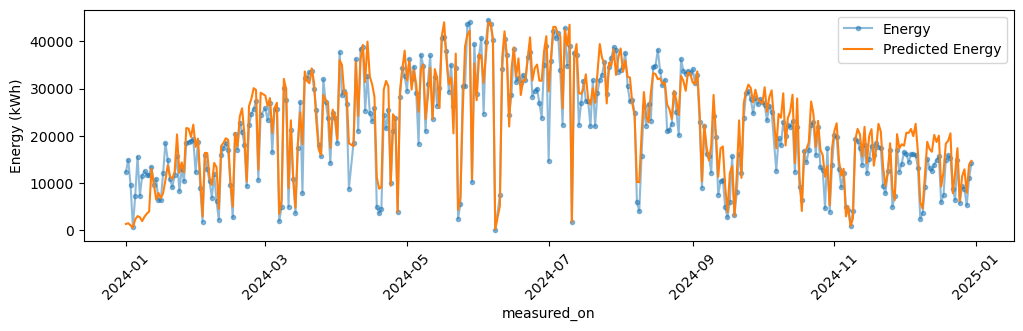

In [59]:

start_date = '2021-01-01'
end_date = '2023-12-31'
mask = (df_hourly['measured_on'] >= start_date) & (df_hourly['measured_on'] <= end_date)

train=df_hourly[mask]
mask_val=(df_hourly['measured_on'] >= '2024-01-01') & (df_hourly['measured_on'] <= '2024-12-31')
val=df_hourly[mask_val]

train = train.set_index('measured_on')
val = val.set_index('measured_on')

train_X = train[cols]
val_X = val[cols]
train_y=train["Power"]
val_y=val["Power"]


xgb_gb = XGBRegressor(
    enable_categorical=True,
    n_estimators=800,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=2.0,            
    reg_alpha=1.0,        
    reg_lambda=2.0,       
    random_state=42
)
xgb_gb.fit(train_X, train_y, verbose=False)

xgb_gb_pred=xgb_gb.predict(val_X)

val['date'] = val.index.date
val['Pred_Energy'] = xgb_gb_pred
Energy = val.groupby('date')[['Power', 'Pred_Energy']].sum()
Energy = Energy.rename(columns={'Power': 'Energy'})



axes= Energy['Energy'].plot(marker='.', alpha=0.5, figsize=(12, 3), label='Energy')
plt.plot(Energy.index, Energy['Pred_Energy'], label= 'Predicted Energy')

plt.xticks(rotation=45)    
plt.xlabel('measured_on')
plt.ylabel('Energy (kWh)')
plt.legend()
plt.show()
#Energy.head(5)

In [89]:
#XGB Random Forest 


from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
from sklearn.model_selection import TimeSeriesSplit
import shap



rmse_scores = [0]*3
r2_scores= [0]*3

#DeltaT(0-3) is column with difference between temperature at t hrs and temperature at t-3 hrs
cols = [ 'Temp', 'DeltaT(0-3)', 'Power_factor_inv1', 'Power_factor_inv2', 'Cloud Type', 'TotalCloudCover', 'Humidity', 'Zenith','day_of_year','DeltaT(0-1)']


X = df_hourly[cols]
y = df_hourly['Power']

tscv = TimeSeriesSplit(n_splits=3)

for i, (train_idx, val_idx) in enumerate(tscv.split(X)):
    train_X, val_X = X.iloc[train_idx], X.iloc[val_idx]
    train_y, val_y = y.iloc[train_idx], y.iloc[val_idx]
    
    print(f"Fold {i+1}:")
    print(f"  Train range: {df_hourly.iloc[train_idx[0]].measured_on} to {df_hourly.iloc[train_idx[-1]].measured_on}")
    print(f"  Val range:   {df_hourly.iloc[val_idx[0]].measured_on} to {df_hourly.iloc[val_idx[-1]].measured_on}")
    print("-" * 70)
    
    
    from xgboost import XGBRFRegressor
    
    xgb_rf = XGBRFRegressor(n_estimators=800,max_depth=6,subsample=0.8, colsample_bynode=0.8, 
                            enable_categorical=True, 
                            gamma=1.0, reg_alpha=2.0, reg_lambda=2.5)
    xgb_rf.fit(train_X, train_y)

    xgb_rf_pred=xgb_rf.predict(val_X)
    
    rmse_scores[i]=root_mean_squared_error(val_y,xgb_rf_pred)
    r2_scores[i]=r2_score(val_y,xgb_rf_pred)
    





print(f'RMSEs on each fold: \n {np.round(rmse_scores,0)}')
print(f'Mean RMSE: {np.round(np.mean(rmse_scores, axis = 0),0)}')
print(f'Standard deviation: {np.round(np.std(rmse_scores, axis = 0),0)}')
print(f'r2 on each fold: \n {np.round(r2_scores,2)}')
print(f'Mean r2: {np.round(np.mean(r2_scores, axis = 0),2)}')
print(f'Standard deviation: {np.round(np.std(r2_scores, axis = 0),2)}')


Fold 1:
  Train range: 2021-01-01 15:00:00+00:00 to 2021-12-14 20:00:00+00:00
  Val range:   2021-12-14 21:00:00+00:00 to 2022-11-27 16:00:00+00:00
----------------------------------------------------------------------
Fold 2:
  Train range: 2021-01-01 15:00:00+00:00 to 2022-11-27 16:00:00+00:00
  Val range:   2022-11-27 17:00:00+00:00 to 2023-11-15 16:00:00+00:00
----------------------------------------------------------------------
Fold 3:
  Train range: 2021-01-01 15:00:00+00:00 to 2023-11-15 16:00:00+00:00
  Val range:   2023-11-15 17:00:00+00:00 to 2024-12-30 21:00:00+00:00
----------------------------------------------------------------------
RMSEs on each fold: 
 [694. 598. 815.]
Mean RMSE: 702.0
Standard deviation: 89.0
r2 on each fold: 
 [0.74 0.81 0.6 ]
Mean r2: 0.72
Standard deviation: 0.09


/var/folders/f4/xfd055z54dzc8gv8yp56gc7h0000gn/T/ipykernel_36254/1296189500.py:34: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  plt.plot(Energy.index, Energy['Pred_Energy'], label= 'Predicted Energy')


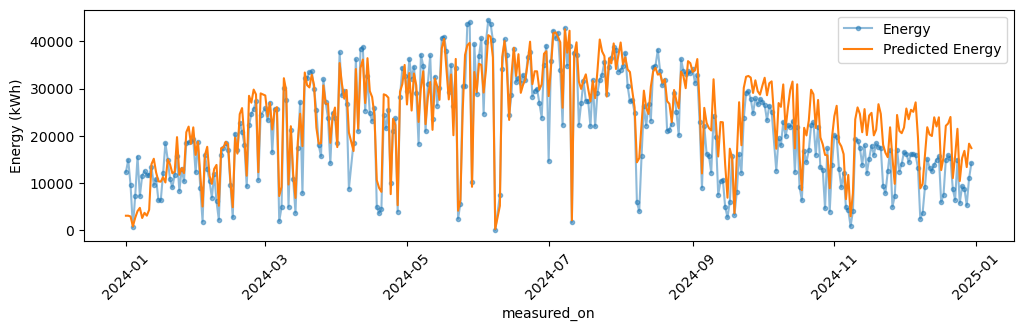

In [61]:
start_date = '2021-01-01'
end_date = '2023-12-31'
mask = (df_hourly['measured_on'] >= start_date) & (df_hourly['measured_on'] <= end_date)

train=df_hourly[mask]
mask_val=(df_hourly['measured_on'] >= '2024-01-01') & (df_hourly['measured_on'] <= '2024-12-31')
val=df_hourly[mask_val]

train = train.set_index('measured_on')
val = val.set_index('measured_on')

train_X = train[cols]
val_X = val[cols]
train_y=train["Power"]
val_y=val["Power"]


xgb_rf = XGBRFRegressor(n_estimators=800,max_depth=6,subsample=0.8, colsample_bynode=0.8, 
                            enable_categorical=True, 
                            gamma=1.0, reg_alpha=2.0, reg_lambda=2.5)
xgb_rf.fit(train_X, train_y)

xgb_rf_pred=xgb_rf.predict(val_X)

val['date'] = val.index.date
val['Pred_Energy'] = xgb_rf_pred
Energy = val.groupby('date')[['Power', 'Pred_Energy']].sum()
Energy = Energy.rename(columns={'Power': 'Energy'})



axes= Energy['Energy'].plot(marker='.', alpha=0.5, figsize=(12, 3), label='Energy')
plt.plot(Energy.index, Energy['Pred_Energy'], label= 'Predicted Energy')

plt.xticks(rotation=45)    
plt.xlabel('measured_on')
plt.ylabel('Energy (kWh)')
plt.legend()
plt.show()
#Energy.head(5)

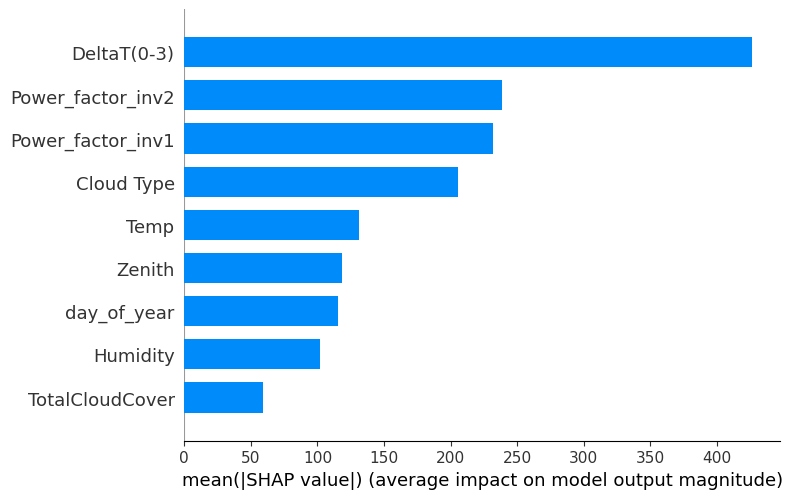

In [62]:
import shap
explainer = shap.TreeExplainer(xgb_gb)
shap_values = explainer.shap_values(val_X)
shap.summary_plot(shap_values, val_X, plot_type="bar")

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

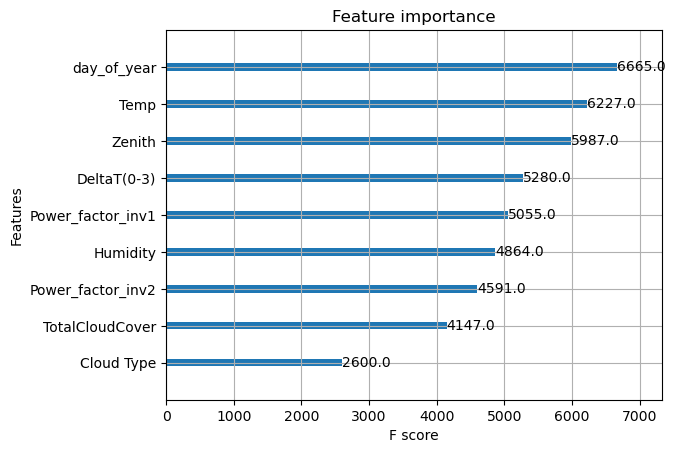

In [65]:
import xgboost
xgboost.plot_importance(xgb_gb)

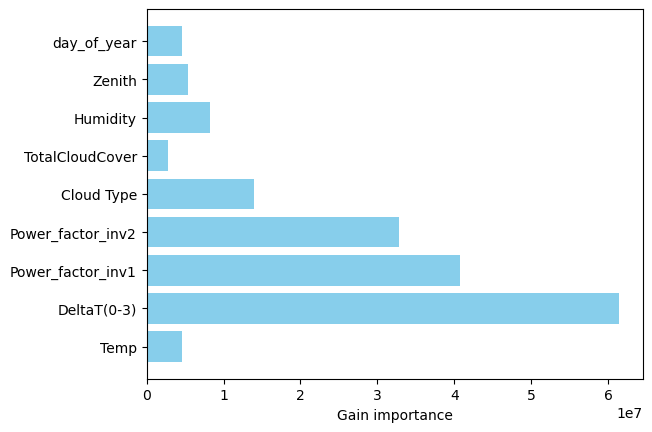

In [69]:
gain_importance = xgb_gb.get_booster().get_score(importance_type='gain')
labels = list(gain_importance.keys())
values = list(gain_importance.values())
plt.barh(labels, values, color='skyblue')
plt.xlabel("Gain importance")
plt.show()